In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning Project/adult_data.csv')

df.columns = ['age','workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation',
             'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'salary']

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
def handle_capital_gain(df):
  df['capital_gain'] = np.where(df['capital_gain'] == 0, np.nan, df['capital_gain'])
  df['capital_gain'] = np.log(df['capital_gain'])
  df['capital_gain'] = df['capital_gain'].replace(np.nan,0)

In [ ]:
handle_capital_gain(df)

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,7.684324,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0,40,Cuba,<=50K


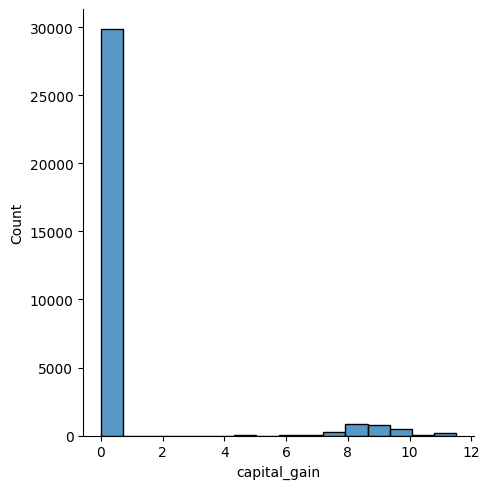

In [ ]:
sns.displot(df['capital_gain'])

In [ ]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,0.734601,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,2.454680,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,11.512915,4356.000000,99.000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df['salary'].unique()

array([' <=50K', ' >50K'], dtype=object)

Removing outliers from hours_erp_week

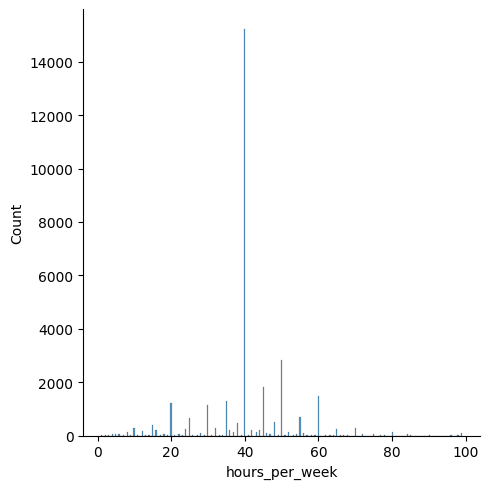

In [ ]:
sns.displot(df['hours_per_week'])

<Axes: ylabel='hours_per_week'>

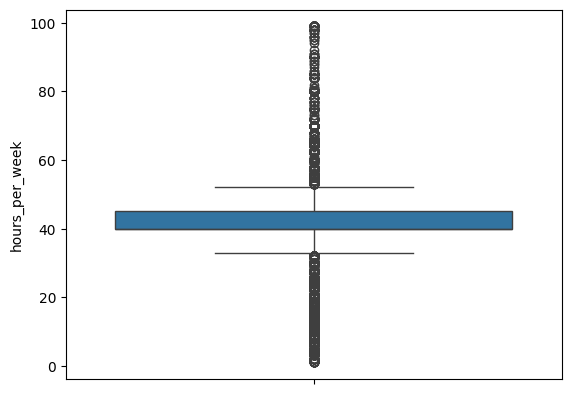

In [ ]:
sns.boxplot(df['hours_per_week'])

In [ ]:
def remove_outlier_hours_per_week(df):
  IQR = df['hours_per_week'].quantile(0.75) - df['hours_per_week'].quantile(0.25)

  lower_range = df['hours_per_week'].quantile(0.25) - (1.5 * IQR)
  upper_range = df['hours_per_week'].quantile(0.75) + (1.5 * IQR)

  df.loc[df['hours_per_week'] <= lower_range, 'hours_per_week'] =lower_range
  df.loc[df['hours_per_week'] >= upper_range, 'hours_per_week'] = upper_range

In [ ]:
remove_outlier_hours_per_week(df)

/tmp/ipython-input-2771694384.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '32.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['hours_per_week'] <= lower_range, 'hours_per_week'] =lower_range


<Axes: ylabel='hours_per_week'>

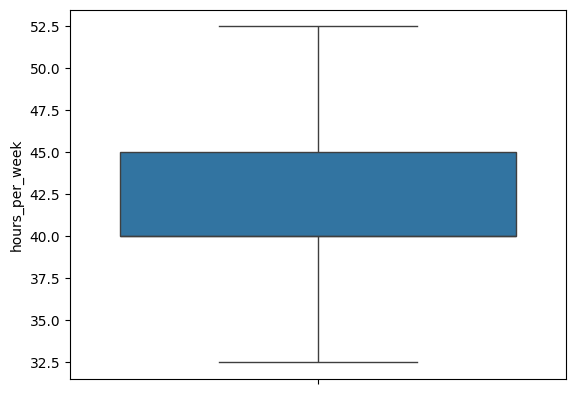

In [ ]:
sns.boxplot(df['hours_per_week'])

Removing outliers from education_num

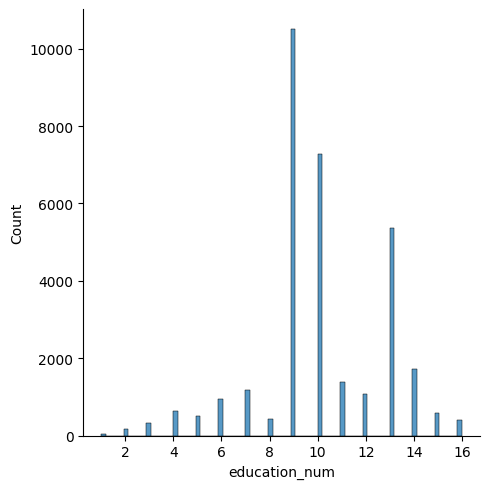

In [ ]:
sns.displot(df['education_num'])

<Axes: ylabel='education_num'>

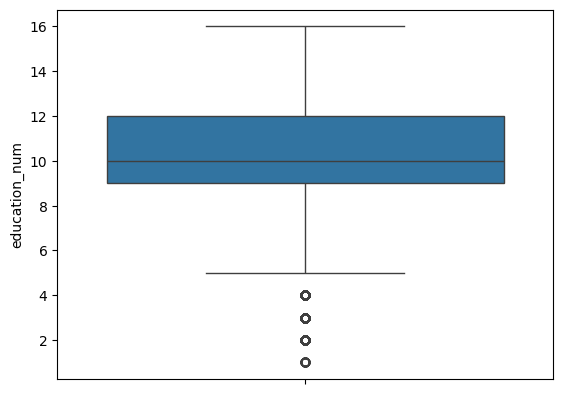

In [ ]:
sns.boxplot(df['education_num'])

In [ ]:
def remove_outlier_education_num(df):
  IQR = df['education_num'].quantile(0.75) - df['education_num'].quantile(0.25)

  lower_range = df['education_num'].quantile(0.25) - (1.5 * IQR)
  upper_range = df['education_num'].quantile(0.75) + (1.5 * IQR)

  df.loc[df['education_num'] <= lower_range, 'education_num'] = lower_range
  df.loc[df['education_num'] >= upper_range, 'education_num'] = upper_range

In [ ]:
remove_outlier_education_num(df)

/tmp/ipython-input-569738557.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['education_num'] <= lower_range, 'education_num'] = lower_range


<Axes: ylabel='education_num'>

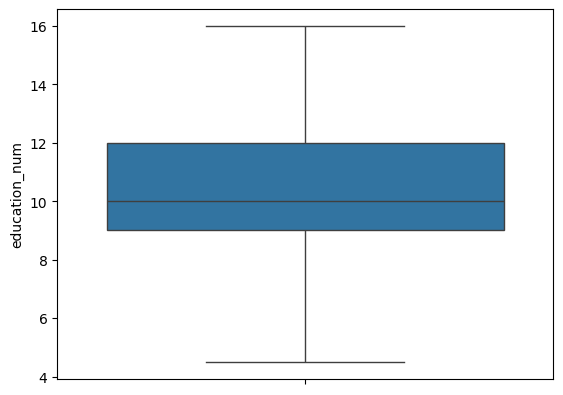

In [ ]:
sns.boxplot(df['education_num'])

Removing outliers from captil_loss

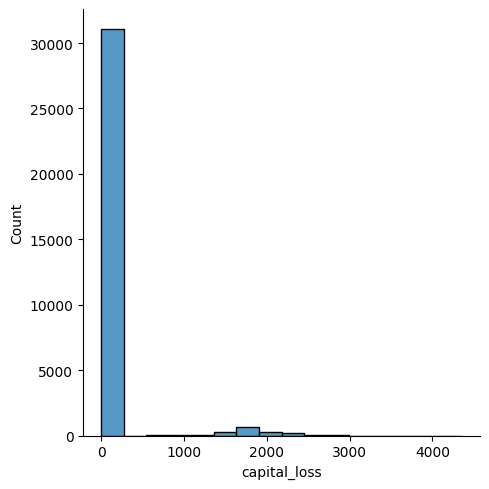

In [ ]:
sns.displot(df['capital_loss'])

In [ ]:
def capital_loss_log(df):
  df['capital_loss'] = np.where(df['capital_loss'] == 0, np.nan, df['capital_loss'])
  df['capital_loss'] = np.log(df['capital_loss'])
  df['capital_loss'] = df['capital_loss'].replace(np.nan,0)

In [ ]:
capital_loss_log(df)

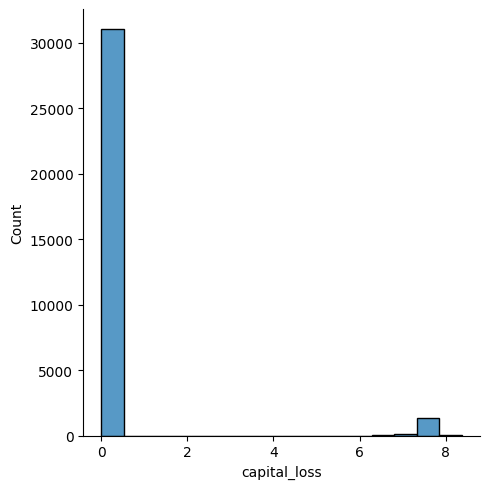

In [ ]:
sns.displot(df['capital_loss'])

<Axes: ylabel='capital_gain'>

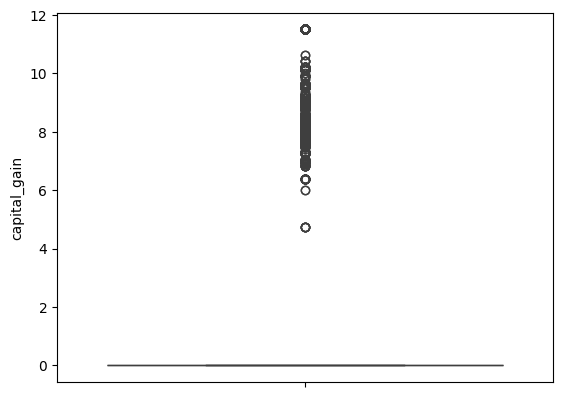

In [ ]:
sns.boxplot(df['capital_gain'])

In [ ]:
def remove_outlier_capital_loss(df):
  IQR = df['capital_loss'].quantile(0.75) - df['capital_loss'].quantile(0.25)

  lower_range = df['capital_loss'].quantile(0.25) - (1.5 * IQR)
  upper_range = df['capital_loss'].quantile(0.75) + (1.5 * IQR)

  df.loc[df['capital_loss'] <= lower_range, 'capital_loss'] = lower_range
  df.loc[df['capital_loss'] >= upper_range, 'capital_loss'] = upper_range

In [ ]:
remove_outlier_capital_loss(df)

<Axes: ylabel='capital_loss'>

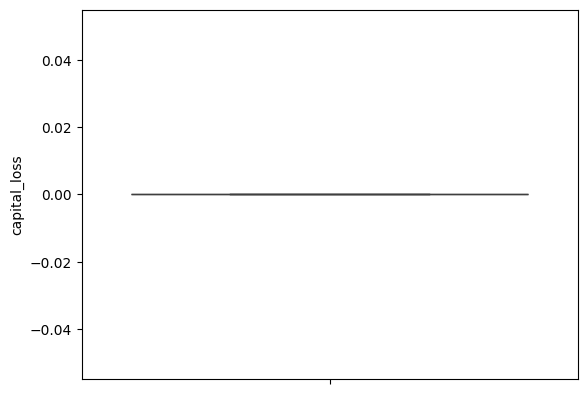

In [ ]:
sns.boxplot(df['capital_loss'])

In [ ]:
def feature_engineering(df):
  ## convert the salary into 1 if salary is greater then 50k else 0
  df['salary'] = np.where(df['salary'] == ' >50K', 1,0)

  ## convert the sex column into 0 and 1 , if male then 1 else 0
  df['sex'] = np.where(df['sex'] == 'Male', 1,0)

  ## do the label encoding in race column (0: 'white', 1: 'Black',2:'Asian-Pac_Islander', 3:'Amer_Indian-Eskimo', 4:'Other')
  label_enco_race = {value:key for key,value in enumerate(df['race'].unique())}
  df['race'] = df['race'].map(label_enco_race)

  ## {0: ' Not-in-family',1: ' Husband'2: ' Wife',3: ' Own-child',4: ' Unmarried',5: ' Other-relative
  label_enco_relation = {value: key for key, value in enumerate(df['relationship'].unique())}
  df['relationship'] = df['relationship'].map(label_enco_relation)

  ## {0: ' Adm-clerical',1: ' Exec-managerial',2: ' Handlers-cleaners',3: ' Prof-specialty',4: ' Other-service',5: ' Sales', 6: ' Craft-repair',7: ' Transport-moving',8: ' Farming-fishing',9: ' Machine-op-inspct', 10: ' Tech-support', 11: ' ?',12: ' Protective-serv',13: ' Armed-Forces', 14: ' Priv-house-serv'}
  df['occupation'] = np.where(df['occupation'] == ' ?', 'Missing', df['occupation'])
  label_enco_occu = {value: key for key, value in enumerate(df['occupation'].unique())}
  ## Replacing ? value with 'Missing'
  df['occupation'] = df['occupation'].map(label_enco_occu)

  ## {0: ' Never-married',1: ' Married-civ-spouse',2: ' Divorced',3: ' Married-spouse-absent',4: ' Separated',5: ' Married-AF-spouse',6: ' Widowed'}
  label_enco_marital_status = {value:key for key,value in enumerate(df['marital_status'].unique())}
  df['marital_status'] = df['marital_status'].map(label_enco_marital_status)

  label_enco_edu = {value:key for key,value in enumerate(df['education'].unique())}
  df['education'] = df['education'].map(label_enco_edu)

  ## {0: ' State-gov'1: ' Self-emp-not-inc',2: ' Private',3: ' Federal-gov',4: ' Local-gov',5: ' ?',6: ' Self-emp-inc',7: ' Without-pay',8: ' Never-worked'}
  df['workclass'] = np.where(df['workclass'] == ' ?', 'Missing', df['workclass'])

  label_enco_workclass = {value : key for key, value in enumerate(df['workclass'].unique())}
  df['workclass'] = df['workclass'].map(label_enco_workclass)

  ## {' United-States': 0,' Cuba': 1,' Jamaica': 2,' India': 3,' ?': 4,' Mexico': 5,' South': 6,' Puerto-Rico': 7,' Honduras': 8,' England': 9,' Canada': 10,' Germany': 11,' Iran': 12,' Philippines': 13,' Italy': 14,' Poland': 15,' Columbia': 16,' Cambodia': 17,' Thailand': 18,' Ecuador': 19,' Laos': 20,' Taiwan': 21,' Haiti': 22,' Portugal': 23,' Dominican-Republic': 24,' El-Salvador': 25,' France': 26,' Guatemala': 27,' China': 28,' Japan': 29,' Yugoslavia': 30,' Peru': 31,' Outlying-US(Guam-USVI-etc)': 32,' Scotland': 33,' Trinadad&Tobago': 34,' Greece': 35,' Nicaragua': 36,' Vietnam': 37,' Hong': 38,' Ireland': 39,' Hungary': 40,' Holand-Netherlands': 41
  df['native_country'] = np.where(df['native_country'] == ' ?', 'Missing', df['native_country'])
  label_enco_country = {value:key for key, value in enumerate(df['native_country'].unique())}
  df['native_country'] = df['native_country'].map(label_enco_country)

# Call the feature engineering function to transform categorical columns to numerical.
feature_engineering(df)

<Axes: >

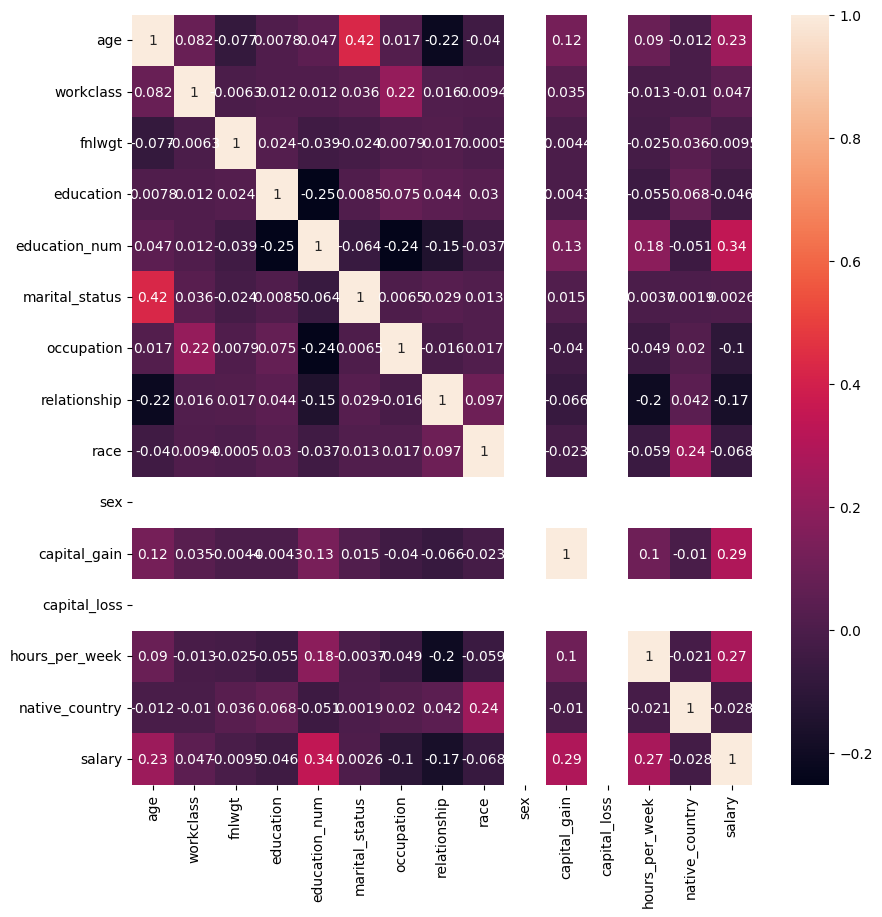

In [ ]:
plt.figure(figsize=(10,10))
corr = df.corr()
sns.heatmap(corr, annot=True)

In [ ]:
df.drop('fnlwgt', axis=1)

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,0,0,13.0,0,0,0,0,0,7.684324,0.0,40.0,0,0
1,50,1,0,13.0,1,1,1,0,0,0.000000,0.0,32.5,0,0
2,38,2,1,9.0,2,2,0,0,0,0.000000,0.0,40.0,0,0
3,53,2,2,7.0,1,2,1,1,0,0.000000,0.0,40.0,0,0
4,28,2,0,13.0,1,3,2,1,0,0.000000,0.0,40.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,2,6,12.0,1,10,2,0,0,0.000000,0.0,38.0,0,0
32557,40,2,1,9.0,1,9,1,0,0,0.000000,0.0,40.0,0,1
32558,58,2,1,9.0,6,0,4,0,0,0.000000,0.0,40.0,0,0
32559,22,2,1,9.0,0,0,3,0,0,0.000000,0.0,32.5,0,0


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,salary
0,39,0,77516,0,13.0,0,0,0,0,0,7.684324,0.0,40.0,0,0
1,50,1,83311,0,13.0,1,1,1,0,0,0.000000,0.0,32.5,0,0
2,38,2,215646,1,9.0,2,2,0,0,0,0.000000,0.0,40.0,0,0
3,53,2,234721,2,7.0,1,2,1,1,0,0.000000,0.0,40.0,0,0
4,28,2,338409,0,13.0,1,3,2,1,0,0.000000,0.0,40.0,1,0


train_test_split


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
sc = StandardScaler()

In [ ]:
X = df[['age', 'workclass', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
          'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']]

In [ ]:
y = df['salary']

In [ ]:
y.value_counts()

,count
salary,
0,24720
1,7841


In [ ]:
X = sc.fit_transform(X)

In [ ]:
X

array([[ 0.03067056, -1.88460023, -0.99158435, ...,  0.        ,
        -0.194354  , -0.25574647],
       [ 0.83710898, -1.0687461 , -0.99158435, ...,  0.        ,
        -1.40659071, -0.25574647],
       [-0.04264203, -0.25289198, -0.70202542, ...,  0.        ,
        -0.194354  , -0.25574647],
       ...,
       [ 1.42360965, -0.25289198, -0.70202542, ...,  0.        ,
        -0.194354  , -0.25574647],
       [-1.21564337, -0.25289198, -0.70202542, ...,  0.        ,
        -1.40659071, -0.25574647],
       [ 0.98373415,  3.01052452, -0.70202542, ...,  0.        ,
        -0.194354  , -0.25574647]])

In [ ]:
X_train, X_text, y_train, y_text = train_test_split(X,y, test_size=0.2, random_state =42)

In [ ]:
print('Train data shape: {}'.format(X_train.shape))
print('Text data shape: {}'.format(X_text.shape))

Train data shape: (26048, 13)
Text data shape: (6513, 13)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model = LogisticRegression()

In [ ]:
lg_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = lg_model.predict(X_text)

In [ ]:
result = {
    'Acutal' : y_text,
    'Predicated' : y_pred
}

In [ ]:
pd.DataFrame(result)

,Acutal,Predicated
14160,0,0
27048,0,0
28868,1,0
5667,0,0
7827,0,1
...,...,...
1338,0,1
24534,1,0
18080,1,1
10354,0,0


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
print("Accuracy Score:{}".format(accuracy_score(y_text, y_pred)))
print("Confusion Matrix:\n {}".format(confusion_matrix(y_text,y_pred)))
print("Classification Report:\n {}".format(classification_report(y_text,y_pred)))

Accuracy Score:0.8082296944572394
Confusion Matrix:
 [[4624  318]
 [ 931  640]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88      4942
           1       0.67      0.41      0.51      1571

    accuracy                           0.81      6513
   macro avg       0.75      0.67      0.69      6513
weighted avg       0.79      0.81      0.79      6513

